# DataEcon Notebook
**Coleta, análise e visualização de dados econômicos do Brasil**

Fontes: Banco Central do Brasil (BCB/SGS) · IBGE (SIDRA API)

---
Este notebook fornece funções prontas para:
- Baixar séries do BCB (IPCA, Selic, câmbio, PIB, etc.)
- Baixar tabelas do IBGE (SIDRA)
- Limpar e organizar os dados
- Rodar regressões OLS e IV
- Gerar gráficos formatados para artigos acadêmicos

## 0. Instalação de dependências
Execute uma vez se necessário.

In [32]:
%pip install requests pandas matplotlib statsmodels scipy sidrapy python-bcb seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports e configuração global

In [33]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time
from bcb import sgs
for tentativa in range(5):
    try:
        print(f"Tentando conectar ao BCB (Tentativa {tentativa + 1}/5)...")
        selic = sgs.get({'selic': 4390}, start='01/01/2020')
        print("Sucesso! Dados baixados.")
        display(selic.head())
        break
        
    except Exception as e:
        print("O servidor do Banco Central não respondeu. Aguardando 5 segundos para tentar novamente...")
        time.sleep(5)
import sys
print(sys.executable)
!{sys.executable} -m pip install statsmodels requests pandas numpy matplotlib scipy seaborn openpyxl
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Estilo acadêmico para gráficos ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.figsize': (9, 4.5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.frameon': False,
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
})

CORES = ['#1a3a5c', '#c0392b', '#27ae60', '#8e44ad', '#e67e22']

print('✓ Ambiente configurado')

Tentando conectar ao BCB (Tentativa 1/5)...
O servidor do Banco Central não respondeu. Aguardando 5 segundos para tentar novamente...
Tentando conectar ao BCB (Tentativa 2/5)...
O servidor do Banco Central não respondeu. Aguardando 5 segundos para tentar novamente...
Tentando conectar ao BCB (Tentativa 3/5)...
O servidor do Banco Central não respondeu. Aguardando 5 segundos para tentar novamente...
Tentando conectar ao BCB (Tentativa 4/5)...
O servidor do Banco Central não respondeu. Aguardando 5 segundos para tentar novamente...
Tentando conectar ao BCB (Tentativa 5/5)...
O servidor do Banco Central não respondeu. Aguardando 5 segundos para tentar novamente...
c:\Users\xiterz\AppData\Local\Programs\Python\Python314\python.exe
✓ Ambiente configurado



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 2. Módulo BCB — Banco Central do Brasil

### Séries disponíveis (SGS)
| Código | Série |
|--------|-------|
| 433    | IPCA (% ao mês) |
| 13522  | IPCA acumulado 12 meses |
| 11    | Taxa Selic (% a.a.) |
| 432   | Taxa de câmbio BRL/USD |
| 4380  | PIB nominal (R$ milhões) |
| 24363 | Taxa de desemprego (PNAD) |
| 7326  | Dívida pública bruta (% PIB) |
| 1453  | M1 — meio circulante + depósitos à vista |
| 1383  | Crédito total (% PIB) |

In [34]:
import requests
import pandas as pd

def bcb_serie(codigo, inicio):
    url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados'
    params = {'formato': 'json', 'dataInicial': inicio}
    
    try:
        # Aumentei para 60 segundos. Se o BCB estiver lerdo, o Python espera.
        resp = requests.get(url, params=params, timeout=60)
        
        if resp.status_code == 200:
            df = pd.DataFrame(resp.json())
            df.index = pd.to_datetime(df['data'], format='%d/%m/%Y')
            df = df.drop('data', axis=1)
            df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
            return df
        else:
            print(f" -> Erro no código {codigo}: Status {resp.status_code}")
            return pd.DataFrame()
    except Exception as e:
        print(f" -> Timeout ou erro na conexão da série {codigo}")
        return pd.DataFrame()

def bcb_multiplas(codigos, inicio):
    df_final = pd.DataFrame()
    for nome, codigo in codigos.items():
        print(f"Coletando {nome} (SGS {codigo})...", end=" ", flush=True)
        
        df_temp = bcb_serie(codigo, inicio)
        
        if not df_temp.empty:
            df_temp.columns = [nome]
            if df_final.empty:
                df_final = df_temp
            else:
                df_final = df_final.join(df_temp, how='outer')
            print("OK")
        else:
            print("Falhou")
            
    if not df_final.empty:
        df_final.dropna(inplace=True)
    return df_final

In [35]:
# ── Exemplo: baixar IPCA e Selic desde 2020 ─────────────────────────────────
print('Baixando dados do BCB...')
macro = bcb_multiplas(
    {'IPCA_mensal': 433, 'Selic': 4390, 'Cambio': 432, 'Desemprego': 24363},
    inicio='01/01/2020'
)
macro.head()

Baixando dados do BCB...
Coletando IPCA_mensal (SGS 433)... OK
Coletando Selic (SGS 4390)... OK
Coletando Cambio (SGS 432)... OK
Coletando Desemprego (SGS 24363)... OK


,IPCA_mensal,Selic,Cambio,Desemprego
data,,,,
2020-01-01,0.21,0.38,4.50,93.56556
2020-02-01,0.25,0.29,4.50,94.01958
2020-03-01,0.07,0.34,4.25,95.26169
2020-04-01,-0.31,0.28,3.75,83.69457
2020-05-01,-0.38,0.24,3.75,84.23566


---
## 3. Módulo IBGE — SIDRA API

### Como encontrar o código de uma tabela?
Acesse [sidra.ibge.gov.br](https://sidra.ibge.gov.br) → pesquise o indicador → o número da tabela aparece na URL.  

### Tabelas úteis
| Tabela | Descrição |
|--------|----------|
| 1737   | IPCA — variação mensal |
| 5932   | PIB trimestral (volume) |
| 6318   | Rendimento médio do trabalho (PNAD) |
| 4099   | Taxa de desocupação por UF |
| 3939   | Expectativa de vida ao nascer |
| 9422   | Contas nacionais anuais |

In [36]:
def ibge_tabela(tabela: int, variaveis: str = 'allxp',
                periodos: str = 'all', nivel: str = 'N1',
                classificacoes: dict = None) -> pd.DataFrame:
    """
    Baixa dados da API SIDRA do IBGE.
    """
    nivel_cod = {'N1': 'n1/all', 'N2': 'n2/all', 'N3': 'n3/all', 'N6': 'n6/all'}
    geo = nivel_cod.get(nivel, nivel)

    class_str = ''
    if classificacoes:
        parts = [f'c{c}/{"|".join(map(str, v))}' for c, v in classificacoes.items()]
        class_str = '/' + '/'.join(parts)

    url = (f'https://apisidra.ibge.gov.br/values'
           f'/t/{tabela}/{geo}/v/{variaveis}/p/{periodos}{class_str}')

    resp = requests.get(url, timeout=20)
    resp.raise_for_status()
    dados = resp.json()

    if len(dados) <= 1:
        print('Nenhum dado retornado. Verifique os parâmetros.')
        return pd.DataFrame()

    # --- A CORREÇÃO ESTÁ AQUI ---
    # Cria o DataFrame com os dados (a partir da segunda linha)
    df = pd.DataFrame(dados[1:])
    
    # Usa a primeira linha (dados[0]) para renomear as colunas corretamente
    df.rename(columns=dados[0], inplace=True)
    # ----------------------------

    rename = {
        'Valor': 'valor', 'Mês': 'periodo', 'Ano': 'periodo',
        'Trimestre': 'periodo', 'Unidade da Federação': 'uf',
        'Município': 'municipio'
    }
    df.rename(columns={k: v for k, v in rename.items() if k in df.columns}, inplace=True)

    if 'valor' in df.columns:
        df['valor'] = pd.to_numeric(df['valor'].astype(str).str.replace(',', '.'), errors='coerce')

    return df

print('✓ Funções IBGE prontas e corrigidas (Versão Final)')

✓ Funções IBGE prontas e corrigidas (Versão Final)


In [37]:
# ── Exemplo: PIB trimestral (tabela 5932) ────────────────────────────────────
print('Baixando PIB trimestral do IBGE...')
pib = ibge_tabela(tabela=5932, variaveis='6564', periodos='all', nivel='N1')
print(f'Registros obtidos: {len(pib)}')
pib.head()

Baixando PIB trimestral do IBGE...
Registros obtidos: 121


,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,valor,Brasil (Código),Brasil,Variável (Código),Variável,Trimestre (Código),periodo,Setores e subsetores (Código),Setores e subsetores
0,1,Brasil,,,NaN,1,Brasil,6564,Taxa trimestre contra trimestre imediatamente ...,199601,1º trimestre 1996,0,
1,1,Brasil,2,%,NaN,1,Brasil,6564,Taxa trimestre contra trimestre imediatamente ...,199602,2º trimestre 1996,0,
2,1,Brasil,2,%,NaN,1,Brasil,6564,Taxa trimestre contra trimestre imediatamente ...,199603,3º trimestre 1996,0,
3,1,Brasil,2,%,NaN,1,Brasil,6564,Taxa trimestre contra trimestre imediatamente ...,199604,4º trimestre 1996,0,
4,1,Brasil,2,%,NaN,1,Brasil,6564,Taxa trimestre contra trimestre imediatamente ...,199701,1º trimestre 1997,0,


---
## 4. Limpeza e transformações

In [38]:
def ipca_acumulado(serie_mensal: pd.Series, janela: int = 12) -> pd.Series:
    """Calcula IPCA acumulado em N meses a partir da série mensal em %."""
    fator = (1 + serie_mensal / 100)
    acum = fator.rolling(janela).apply(lambda x: x.prod(), raw=True) - 1
    return (acum * 100).rename(f'IPCA_acum{janela}m')


def deflacionar(serie_nominal: pd.Series, ipca_mensal: pd.Series,
                base_periodo: str) -> pd.Series:
    """
    Deflaciona uma série nominal usando o IPCA.

    Parâmetros
    ----------
    serie_nominal : pd.Series — valores nominais com índice DatetimeIndex
    ipca_mensal   : pd.Series — IPCA mensal (%) com índice DatetimeIndex
    base_periodo  : str       — período base para deflação, ex: '2020-01'
    """
    indice = (1 + ipca_mensal / 100).cumprod()
    indice = indice / indice.loc[base_periodo]
    alinhado = serie_nominal.resample('MS').mean()
    return (alinhado / indice).rename(f'{serie_nominal.name}_real_{base_periodo}')


def variacao_anual(serie: pd.Series) -> pd.Series:
    """Calcula variação percentual anual de uma série mensal."""
    return serie.pct_change(12).mul(100).rename(f'{serie.name}_var_anual')


def resumo_estatistico(df: pd.DataFrame) -> pd.DataFrame:
    """Resumo estatístico formatado: média, desvio, min, max, obs."""
    desc = df.describe().T
    desc['missing'] = df.isnull().sum()
    return desc[['count', 'missing', 'mean', 'std', 'min', '50%', 'max']].round(3)


print('✓ Funções de limpeza prontas')

✓ Funções de limpeza prontas


In [39]:
# ── Aplicar transformações aos dados do BCB ──────────────────────────────────
if 'IPCA_mensal' in macro.columns and not macro['IPCA_mensal'].dropna().empty:
    macro['IPCA_12m'] = ipca_acumulado(macro['IPCA_mensal'], janela=12)
    print('✓ IPCA acumulado 12 meses calculado')

resumo_estatistico(macro)

✓ IPCA acumulado 12 meses calculado


,count,missing,mean,std,min,50%,max
IPCA_mensal,76.0,0,0.471,0.418,-0.680,0.435,1.620
Selic,76.0,0,0.782,0.363,0.130,0.920,1.280
Cambio,76.0,0,9.961,4.660,2.000,11.500,15.000
Desemprego,76.0,0,101.933,6.778,83.695,101.721,117.927
IPCA_12m,65.0,11,6.164,2.510,3.162,5.131,12.131


---
## 5. Visualizações

In [40]:
def plot_serie(serie: pd.Series, titulo: str, ylabel: str,
               cor: str = '#1a3a5c', salvar: str = None):
    """Gráfico de série temporal com estilo acadêmico."""
    fig, ax = plt.subplots()
    ax.plot(serie.index, serie.values, color=cor, linewidth=1.5)
    ax.fill_between(serie.index, serie.values, alpha=0.08, color=cor)
    ax.set_title(titulo, pad=10)
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(plt.MaxNLocator(8))
    plt.xticks(rotation=30, ha='right')
    if salvar:
        fig.savefig(salvar)
        print(f'Figura salva: {salvar}')
    plt.tight_layout()
    plt.show()


def plot_duplo(s1: pd.Series, s2: pd.Series, titulo: str,
               label1: str = None, label2: str = None, salvar: str = None):
    """Gráfico com dois eixos Y para séries em escalas diferentes."""
    fig, ax1 = plt.subplots()
    c1, c2 = CORES[0], CORES[1]

    ax1.plot(s1.index, s1.values, color=c1, linewidth=1.5, label=label1 or s1.name)
    ax1.set_ylabel(label1 or s1.name, color=c1)
    ax1.tick_params(axis='y', labelcolor=c1)

    ax2 = ax1.twinx()
    ax2.plot(s2.index, s2.values, color=c2, linewidth=1.5, linestyle='--',
             label=label2 or s2.name)
    ax2.set_ylabel(label2 or s2.name, color=c2)
    ax2.tick_params(axis='y', labelcolor=c2)
    ax2.spines['right'].set_visible(True)
    ax2.spines['top'].set_visible(False)

    linhas = ax1.get_lines() + ax2.get_lines()
    ax1.legend(linhas, [l.get_label() for l in linhas], loc='upper left')
    ax1.set_title(titulo, pad=10)
    ax1.xaxis.set_major_locator(plt.MaxNLocator(8))
    plt.xticks(rotation=30, ha='right')
    if salvar:
        fig.savefig(salvar)
    plt.tight_layout()
    plt.show()


def plot_correlacao(df: pd.DataFrame, titulo: str = 'Matriz de correlação',
                    salvar: str = None):
    """Heatmap de correlação com anotações."""
    corr = df.corr()
    n = len(corr)
    fig, ax = plt.subplots(figsize=(n * 1.4 + 1, n * 1.2 + 1))

    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr.columns)

    for i in range(n):
        for j in range(n):
            val = corr.iloc[i, j]
            cor_txt = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=9, color=cor_txt)

    ax.set_title(titulo, pad=12)
    if salvar:
        fig.savefig(salvar)
    plt.tight_layout()
    plt.show()


print('✓ Funções de visualização prontas')

✓ Funções de visualização prontas


Figura salva: ipca_mensal.png


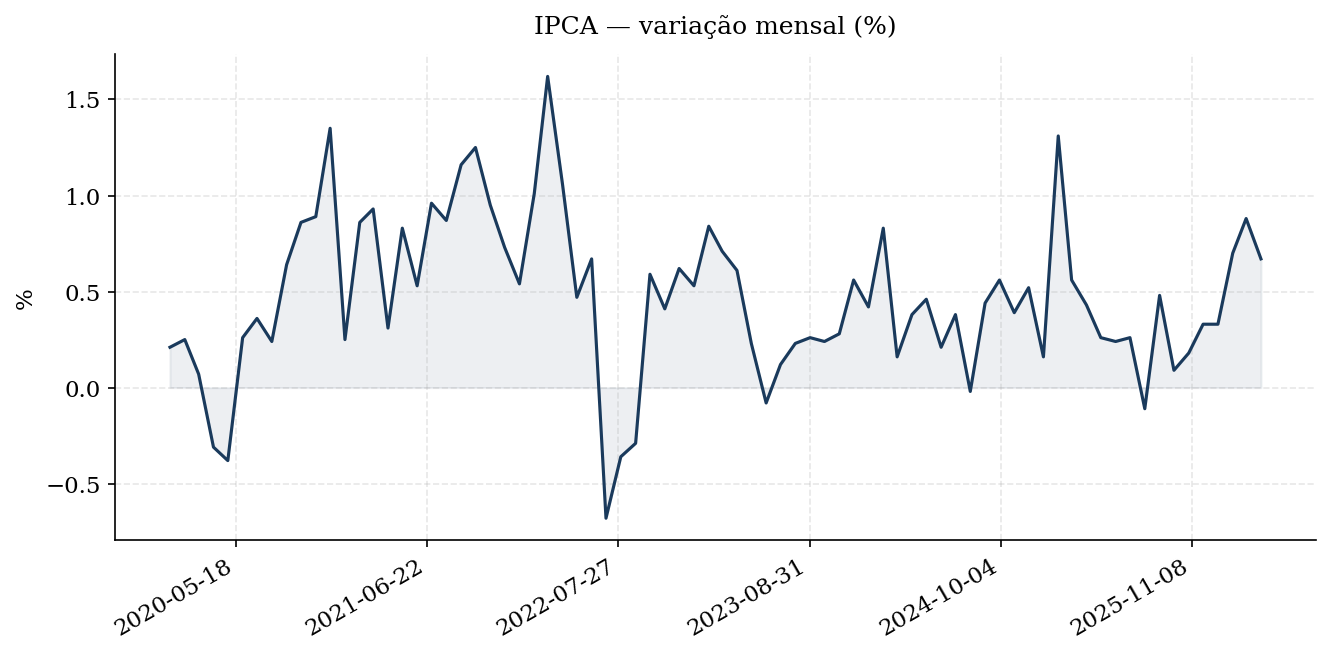

In [41]:
# ── Gráfico: IPCA mensal ─────────────────────────────────────────────────────
if 'IPCA_mensal' in macro.columns:
    plot_serie(
        macro['IPCA_mensal'].dropna(),
        titulo='IPCA — variação mensal (%)',
        ylabel='%',
        salvar='ipca_mensal.png'
    )

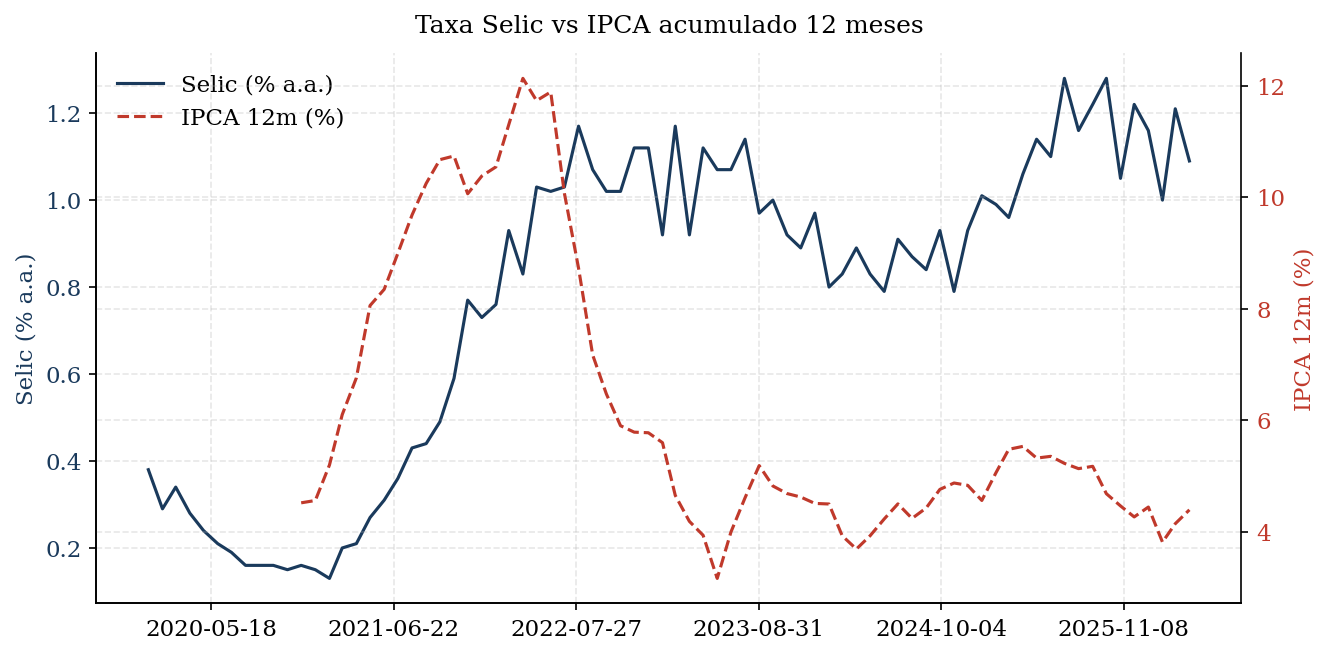

In [42]:
# ── Gráfico: Selic vs IPCA 12m ───────────────────────────────────────────────
if 'Selic' in macro.columns and 'IPCA_12m' in macro.columns:
    plot_duplo(
        macro['Selic'].dropna(),
        macro['IPCA_12m'].dropna(),
        titulo='Taxa Selic vs IPCA acumulado 12 meses',
        label1='Selic (% a.a.)',
        label2='IPCA 12m (%)',
        salvar='selic_vs_ipca.png'
    )

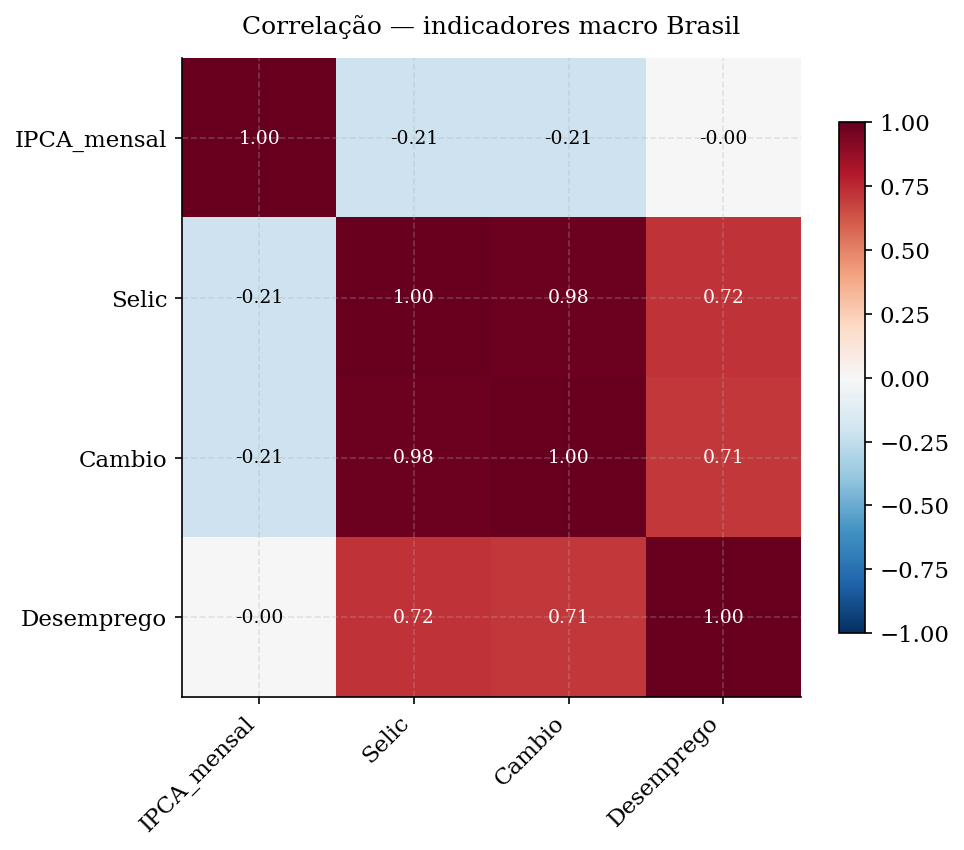

In [43]:
# ── Matriz de correlação ─────────────────────────────────────────────────────
cols_corr = [c for c in ['IPCA_mensal', 'Selic', 'Cambio', 'Desemprego'] if c in macro.columns]
if len(cols_corr) >= 2:
    plot_correlacao(macro[cols_corr].dropna(), titulo='Correlação — indicadores macro Brasil')

---
## 6. Econometria — Regressões

In [44]:
# ==============================================================================
# MÓDULO DE ECONOMETRIA E REGRESSÃO BLINDADO
# ==============================================================================

def ols(df, y, X):
    """
    Roda regressão OLS tratando automaticamente limpeza de dados, 
    conversão de tipos e remoção de valores nulos/infinitos.
    """
    df_clean = df[[y] + X].copy()
    
    df_clean = df_clean.apply(pd.to_numeric, errors='coerce')
    
    df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_clean.dropna(inplace=True)
    
    if len(df_clean) < 15:
        print(f"Erro: Restaram apenas {len(df_clean)} linhas válidas após alinhar as datas.")
        return None
        
    Y_target = df_clean[y]
    X_features = sm.add_constant(df_clean[X])
    
    try:
        modelo = sm.OLS(Y_target, X_features).fit(cov_type='HC3')
        return modelo
    except np.linalg.LinAlgError:
        print("Erro de Álgebra Linear (SVD): As variáveis X são perfeitamente colineares.")
        return None

# ==============================================================================
# EXECUÇÃO DO MODELO MACROECONÔMICO
# ==============================================================================

variaveis_modelo = ['Selic', 'IPCA_mensal', 'Cambio']

cols_existentes = [c for c in variaveis_modelo if c in macro.columns]

if len(cols_existentes) == len(variaveis_modelo):
    print("1. Alinhando frequências temporais (Diário -> Mensal)...")
    
    macro_num = macro[cols_existentes].apply(pd.to_numeric, errors='coerce')
    dados_regressao = macro_num.resample('MS').mean()
    
    print("2. Rodando regressão OLS...\n")
    modelo_fit = ols(dados_regressao, y='Selic', X=['IPCA_mensal', 'Cambio'])
    
    if modelo_fit:
        print(modelo_fit.summary())
else:
    faltam = set(variaveis_modelo) - set(cols_existentes)
    print(f"A regressão foi abortada porque as seguintes séries não estão no dataset: {faltam}")

def tabela_latex(resultados: list, nomes: list = None) -> str:
    """
    Gera uma tabela LaTeX com múltiplas regressões lado a lado.
    Compatível com o pacote booktabs.

    Parâmetros
    ----------
    resultados : list — lista de ResultWrapper do statsmodels
    nomes      : list — nomes das colunas (Modelo 1, 2, ...)

    Retorna
    -------
    str com código LaTeX da tabela
    """
    if nomes is None:
        nomes = [f'({i+1})' for i in range(len(resultados))]

    # coletar todos os regressores
    all_params = []
    for r in resultados:
        for p in r.params.index:
            if p not in all_params:
                all_params.append(p)

    ncols = len(resultados)
    col_spec = 'l' + 'c' * ncols

    lines = []
    lines.append(r'\begin{table}[htbp]')
    lines.append(r'\centering')
    lines.append(r'\caption{Resultados das Regressões}')
    lines.append(r'\label{tab:regressoes}')
    lines.append(r'\begin{tabular}{' + col_spec + '}')
    lines.append(r'\toprule')

    header = ' & ' + ' & '.join(nomes) + r' \\'
    lines.append(header)
    lines.append(r'\midrule')

    def stars(pval):
        if pval < 0.01: return '***'
        if pval < 0.05: return '**'
        if pval < 0.10: return '*'
        return ''

    for param in all_params:
        row_coef = param.replace('_', '\\_')
        row_se = ''
        for r in resultados:
            if param in r.params:
                coef = r.params[param]
                se = r.bse[param]
                pval = r.pvalues[param]
                row_coef += f' & {coef:.4f}{stars(pval)}'
                row_se += f' & ({se:.4f})'
            else:
                row_coef += ' & --'
                row_se += ' & '
        lines.append(row_coef + r' \\')
        lines.append(row_se + r' \\')

    lines.append(r'\midrule')

    obs_row = 'Obs.' + ''.join([f' & {int(r.nobs)}' for r in resultados]) + r' \\'
    r2_row = '$R^2$' + ''.join([f' & {r.rsquared:.3f}' for r in resultados]) + r' \\'
    lines.append(obs_row)
    lines.append(r2_row)

    lines.append(r'\bottomrule')
    lines.append(r'\multicolumn{' + str(ncols+1) + r'}{l}{\small Erros padrão robustos (HC3) entre parênteses.}')
    lines.append(r'\multicolumn{' + str(ncols+1) + r'}{l}{\small * p$<$0.10, ** p$<$0.05, *** p$<$0.01}')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')

    return '\n'.join(lines)


print('✓ Funções de regressão prontas')

1. Alinhando frequências temporais (Diário -> Mensal)...
2. Rodando regressão OLS...

                            OLS Regression Results                            
Dep. Variable:                  Selic   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     1499.
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           5.38e-60
Time:                        23:38:41   Log-Likelihood:                 100.02
No. Observations:                  76   AIC:                            -194.0
Df Residuals:                      73   BIC:                            -187.0
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

In [45]:
# ── Exemplo: Selic explicada por IPCA e câmbio ───────────────────────────────

colunas_necessarias = ['Selic', 'IPCA_mensal', 'Cambio', 'Desemprego']
colunas_presentes = [c for c in colunas_necessarias if c in macro.columns]

# Verifica se todas as séries foram baixadas antes de tentar rodar o modelo
if len(colunas_presentes) == len(colunas_necessarias):
    # Alinhar séries por período
    dados_reg = macro[colunas_necessarias].resample('MS').mean().dropna()
    
    if len(dados_reg) > 20:
        res = ols(dados_reg, y='Selic', X=['IPCA_mensal', 'Cambio', 'Desemprego'])
    else:
        print('Dados insuficientes para a regressão. Ajuste o período de coleta.')
else:
    faltam = set(colunas_necessarias) - set(colunas_presentes)
    print(f'A regressão não pôde ser executada. Faltam as séries: {faltam}')

In [46]:
# ── Exemplo: Selic explicada por IPCA e câmbio ───────────────────────────────
# Alinhar séries por período
dados_reg = macro[['Selic', 'IPCA_mensal', 'Cambio', 'Desemprego']].resample('MS').mean().dropna()

if len(dados_reg) > 20:
    res = ols(dados_reg, y='Selic', X=['IPCA_mensal', 'Cambio', 'Desemprego'])
else:
    print('Dados insuficientes para a regressão de exemplo. Ajuste o período de coleta.')

In [47]:
# ── Exportar tabela LaTeX ─────────────────────────────────────────────────────
if len(dados_reg) > 20:
    latex = tabela_latex([res], nomes=['(1)'])
    print(latex)

    with open('tabela_regressao.tex', 'w', encoding='utf-8') as f:
        f.write(latex)
    print('\n✓ Arquivo tabela_regressao.tex gerado')

\begin{table}[htbp]
\centering
\caption{Resultados das Regressões}
\label{tab:regressoes}
\begin{tabular}{lc}
\toprule
 & (1) \\
\midrule
const & -0.2696* \\
 & (0.1428) \\
IPCA\_mensal & -0.0121 \\
 & (0.0196) \\
Cambio & 0.0732*** \\
 & (0.0023) \\
Desemprego & 0.0032** \\
 & (0.0016) \\
\midrule
Obs. & 76 \\
$R^2$ & 0.969 \\
\bottomrule
\multicolumn{2}{l}{\small Erros padrão robustos (HC3) entre parênteses.}
\multicolumn{2}{l}{\small * p$<$0.10, ** p$<$0.05, *** p$<$0.01}
\end{tabular}
\end{table}

✓ Arquivo tabela_regressao.tex gerado


---
## 7. Teste de raiz unitária — Dickey-Fuller aumentado

In [48]:
def adf_test(serie: pd.Series, nome: str = None, niveis: bool = True):
    """
    Teste ADF com output formatado.

    Parâmetros
    ----------
    serie  : pd.Series — série temporal
    nome   : str       — nome para exibição
    niveis : bool      — testar em nível e primeira diferença
    """
    nome = nome or serie.name or 'série'
    s = serie.dropna()

    def _rodar(x, label):
        stat, pval, lags, nobs, crit, _ = adfuller(x, autolag='AIC')
        estacionaria = pval < 0.05
        simbolo = '✓ estacionária' if estacionaria else '✗ raiz unitária'
        print(f'  {label:30s}  ADF={stat:7.3f}  p={pval:.4f}  {simbolo}')
        return estacionaria

    print(f'\n── ADF: {nome} ──')
    est_nivel = _rodar(s, 'Nível I(0)')
    if niveis and not est_nivel:
        _rodar(s.diff().dropna(), '1ª diferença I(1)')


# Testar todas as séries disponíveis
for col in macro.columns:
    adf_test(macro[col], nome=col)


── ADF: IPCA_mensal ──
  Nível I(0)                      ADF= -3.450  p=0.0094  ✓ estacionária

── ADF: Selic ──
  Nível I(0)                      ADF= -2.197  p=0.2073  ✗ raiz unitária
  1ª diferença I(1)               ADF= -2.752  p=0.0655  ✗ raiz unitária

── ADF: Cambio ──
  Nível I(0)                      ADF= -2.447  p=0.1289  ✗ raiz unitária
  1ª diferença I(1)               ADF= -1.879  p=0.3420  ✗ raiz unitária

── ADF: Desemprego ──
  Nível I(0)                      ADF= -1.455  p=0.5555  ✗ raiz unitária
  1ª diferença I(1)               ADF= -3.455  p=0.0092  ✓ estacionária

── ADF: IPCA_12m ──
  Nível I(0)                      ADF= -1.571  p=0.4981  ✗ raiz unitária
  1ª diferença I(1)               ADF= -3.610  p=0.0056  ✓ estacionária


---
## 8. Exportação de dados

In [49]:
def exportar(df: pd.DataFrame, nome: str = 'dados_macro', formatos: list = ['csv', 'xlsx']):
    """Exporta o DataFrame em CSV e/ou Excel."""
    for fmt in formatos:
        if fmt == 'csv':
            df.to_csv(f'{nome}.csv', encoding='utf-8-sig', decimal=',')
            print(f'✓ Exportado: {nome}.csv')
        elif fmt == 'xlsx':
            df.to_excel(f'{nome}.xlsx')
            print(f'✓ Exportado: {nome}.xlsx')


exportar(macro, nome='dados_macro_brasil')

✓ Exportado: dados_macro_brasil.csv
✓ Exportado: dados_macro_brasil.xlsx


---
## 9. Referência rápida de códigos BCB

| Código | Série | Periodicidade |
|--------|-------|---------------|
| 433    | IPCA (% mês) | Mensal |
| 13522  | IPCA 12 meses | Mensal |
| 11     | Taxa Selic (% a.a.) | Diária |
| 4390   | Taxa Selic          | Mensal |
| 432    | Câmbio BRL/USD (ptax) | Diária |
| 4380   | PIB nominal | Trimestral |
| 24363  | Desemprego PNAD | Mensal |
| 7326   | Dívida bruta (% PIB) | Mensal |
| 1453   | M1 | Mensal |
| 1383   | Crédito total (% PIB) | Mensal |
| 20257  | IPC-Fipe | Mensal |
| 189    | IGP-M | Mensal |
| 7478   | Resultado primário (% PIB) | Mensal |
| 21082  | Expectativa IPCA 12m (Focus) | Diária |

**Explore mais:** https://www.bcb.gov.br/estatisticas/tabelaespecial

---
*DataEcon Notebook — feito para estudantes de economia*